# ReliFuse with two segmentation experts

This offline demo creates probability masks with two complementary toy `torch.nn.Module` experts, fits ReliFuse on cached development posteriors, and fuses a held-out sample. The toy experts only keep the notebook downloadable and fast—replace their outputs with probabilities from your own frozen segmenters.

In [1]:
import matplotlib.pyplot as plt
import torch

from relifuse import ReliFuse, TrainingConfig, expert_dice_scores, fit, seed_everything
from relifuse.demo import make_synthetic_vessels, predict_with_toy_experts

## 1. Generate predicted probability masks

ReliFuse sees only the two posterior maps below; it never receives the source image.

In [2]:
images, targets = make_synthetic_vessels(count=36, size=48, seed=7)
predictions = predict_with_toy_experts(images)  # [N, K=2, H, W]
train, validation, test = slice(0, 24), slice(24, 32), slice(32, 36)
predictions.shape, targets.shape

(torch.Size([36, 2, 48, 48]), torch.Size([36, 1, 48, 48]))

## 2. Derive validation priors and fit the fusion head

In a real project, use a leakage-free validation split (or out-of-fold predictions) here—not test masks.

In [3]:
quality = expert_dice_scores(predictions[validation], targets[validation], batch_size=8)
seed_everything(42)  # Seed before constructing the trainable fusion head.
model = ReliFuse(num_experts=2, expert_scores=quality)
history = fit(
    model,
    predictions[train],
    targets[train],
    predictions[validation],
    targets[validation],
    config=TrainingConfig(epochs=6, batch_size=4, patience=6, amp=False),
    device="cpu",
)
print("expert validation Dice:", quality.tolist())
print("selected epoch / validation loss:", history.best_epoch, history.best_validation_loss)
print("validation Dice at selected epoch:", history.best_validation_dice)

expert validation Dice: [0.5893777012825012, 0.7580011487007141]
selected epoch / validation loss: 6 0.1587662771344185
validation Dice at selected epoch: 0.9993111789226532


## 3. Fuse a list of masks

This is the intended integration boundary. Keep expert ordering identical to the training stack.

In [4]:
sample = 0
mask_list = [predictions[test][sample, 0], predictions[test][sample, 1]]
model.eval()
with torch.inference_mode():
    details = model(mask_list)
final_probability = details.probabilities[0, 0].cpu()
final_mask = (final_probability >= 0.5).float()

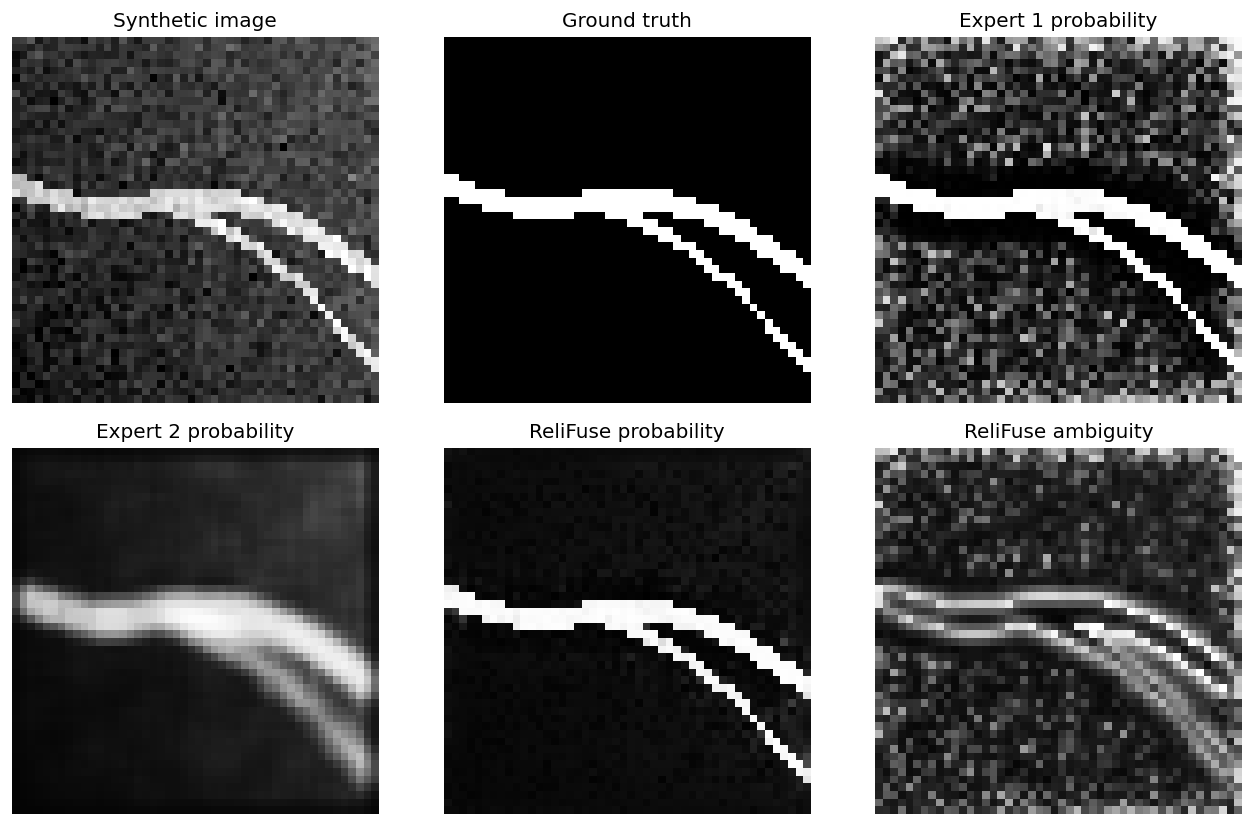

In [5]:
panels = [
    (images[test][sample, 0], "Synthetic image"),
    (targets[test][sample, 0], "Ground truth"),
    (mask_list[0], "Expert 1 probability"),
    (mask_list[1], "Expert 2 probability"),
    (final_probability, "ReliFuse probability"),
    (details.ambiguity[0, 0].cpu(), "ReliFuse ambiguity"),
]
fig, axes = plt.subplots(2, 3, figsize=(11, 7))
for axis, (panel, title) in zip(axes.flat, panels):
    axis.imshow(panel, cmap="gray", vmin=0, vmax=1)
    axis.set_title(title)
    axis.axis("off")
plt.tight_layout()

## Replace the toy experts

For each image, run your frozen segmentation models, apply `sigmoid` if they emit logits, and stack the resulting probabilities as `[N,K,H,W]`. Everything from `expert_dice_scores(...)` onward stays the same. Save expert names/order with `save_checkpoint(...)` before deployment.